<a href="https://colab.research.google.com/github/ysacodes/E-comm-Customer-Churn-Analysis-Prediction/blob/main/e_comm_missing_data_cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ks_2samp
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = pd.read_excel('/content/drive/MyDrive/Hi/E Commerce Dataset.xlsx', sheet_name='E Comm')

# EDA

In [4]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore MaritalStatus  Number

In [5]:
print(df.describe().transpose())

                              count          mean          std      min  \
CustomerID                   5630.0  52815.500000  1625.385339  50001.0   
Churn                        5630.0      0.168384     0.374240      0.0   
Tenure                       5366.0     10.189899     8.557241      0.0   
CityTier                     5630.0      1.654707     0.915389      1.0   
WarehouseToHome              5379.0     15.639896     8.531475      5.0   
HourSpendOnApp               5375.0      2.931535     0.721926      0.0   
NumberOfDeviceRegistered     5630.0      3.688988     1.023999      1.0   
SatisfactionScore            5630.0      3.066785     1.380194      1.0   
NumberOfAddress              5630.0      4.214032     2.583586      1.0   
Complain                     5630.0      0.284902     0.451408      0.0   
OrderAmountHikeFromlastYear  5365.0     15.707922     3.675485     11.0   
CouponUsed                   5374.0      1.751023     1.894621      0.0   
OrderCount               

In [6]:
# Duplicate check
print("Duplicate CustomerIDs:", df.duplicated(subset=['CustomerID']).sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate CustomerIDs: 0
Fully duplicate rows: 0


In [7]:
# Missing values per column
print(df.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


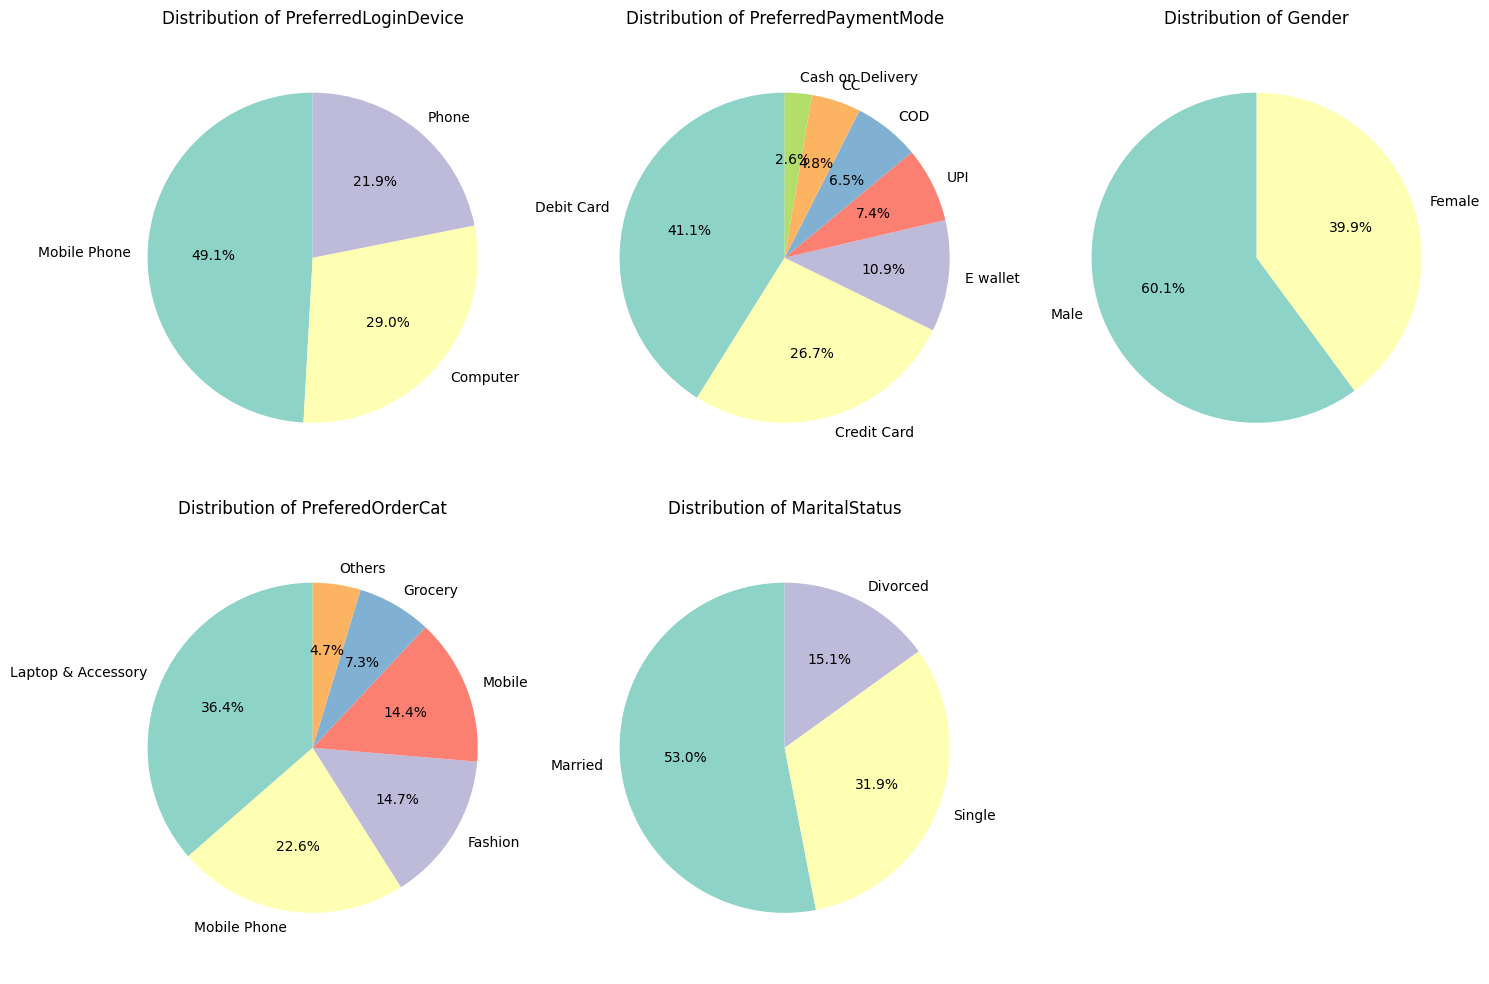

In [8]:
# Distribution of each categorical feature.
# Checked here to spot severe class imbalance or single-category columns
# before they're used as predictors later on.
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                startangle=90, colors=plt.cm.Set3.colors)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].axis('equal')

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Handling Missing Values

In [9]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary['dtype'] = df.loc[:, missing_summary.index].dtypes.values
print(missing_summary)

                             missing_count  missing_pct    dtype
Tenure                                 264         4.69  float64
WarehouseToHome                        251         4.46  float64
HourSpendOnApp                         255         4.53  float64
OrderAmountHikeFromlastYear            265         4.71  float64
CouponUsed                             256         4.55  float64
OrderCount                             258         4.58  float64
DaySinceLastOrder                      307         5.45  float64


Seven numeric columns have missing values: **Tenure, WarehouseToHome, HourSpendOnApp,
OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder**.

To decide how to handle each one, we classify its missingness mechanism:
- **MCAR** (Missing Completely At Random) — missingness is unrelated to any observed or unobserved data. Simple imputation (mean/median) is safe.
- **MAR** (Missing At Random) — missingness is explained by *other observed* features. Multivariate imputation (MICE) is appropriate.
- **MNAR** (Missing Not At Random) — missingness depends on the unobserved value itself. No imputation method fully fixes this without domain assumptions.

**Workflow for each column below:**
1. Compare summary statistics between the *value present* and *value missing* groups as an informal first signal.
2. Run chi-square tests of independence against candidate categorical features (`PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat`, `MaritalStatus`) to formally test for MAR.
3. Impute using MICE (`IterativeImputer`), built only from the features that pass the chi-square test — this is what statistically justifies including them.
4. Run a two-sample Kolmogorov-Smirnov (KS) test comparing the originally observed values against the complete (observed + imputed) column, to confirm imputation didn't distort the distribution.

`CustomerID` (identifier) and `Churn` (the eventual modeling target) are always excluded as predictors, the latter to avoid leaking the label into imputed features.

## Helper functions

In [11]:
CANDIDATE_CATEGORICAL_COLS = [
    'PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
    'PreferedOrderCat', 'MaritalStatus'
]


def compare_missing_groups(data, target_col):
    """Print summary stats for the 'target_col present' vs 'target_col missing' groups."""
    present = data[data[target_col].notnull()]
    missing = data[data[target_col].isnull()]

    numerical_cols = data.select_dtypes(include='number').columns.drop(
        ['CustomerID', target_col], errors='ignore')
    categorical_cols = data.select_dtypes(include='object').columns

    for label, group in [('Present', present), ('Missing', missing)]:
        print(f"--- Group: {target_col} {label} (n={len(group)}) ---")
        print("\nNumerical summary statistics:")
        print(group[numerical_cols].describe().transpose())
        print("\nCategorical distribution (%):")
        for col in categorical_cols:
            print(f"\n{col}:")
            print(group[col].value_counts(normalize=True).mul(100).round(2))
        print()


def chi_square_missingness(data, target_col, candidate_cols, alpha=0.05):
    """
    Chi-square test of independence between target_col's missingness and each
    candidate categorical column. Returns the columns for which the null of
    independence is rejected (p < alpha) -- i.e. justified as MICE predictors.
    """
    is_missing = data[target_col].isna()
    justified = []
    print(f"--- Chi-square tests: is {target_col} missing ~ candidate feature ---\n")
    for col in candidate_cols:
        table = pd.crosstab(data[col], is_missing)
        chi2, p_val, _, _ = chi2_contingency(table)
        verdict = 'JUSTIFIED' if p_val < alpha else 'not significant'
        print(f"{col:<22} chi2={chi2:9.2f}   p={p_val:.4f}   -> {verdict}")
        if p_val < alpha:
            justified.append(col)
    print()
    return justified


def mice_impute_column(data, target_col, categorical_predictors,
                        min_value=None, round_result=False, as_int=False):
    """
    Impute target_col with MICE (IterativeImputer). Predictors are every numeric
    column (excluding CustomerID/Churn/target_col) plus the one-hot-encoded
    categorical_predictors. Fills target_col in place on `data` and returns
    (observed_values, full_column) for the downstream KS distribution check.
    """
    numerical_predictors = (
        data.select_dtypes(include='number')
        .columns.drop(['CustomerID', 'Churn', target_col], errors='ignore')
        .tolist()
    )
    predictors = data[numerical_predictors + categorical_predictors]
    predictors_encoded = pd.get_dummies(
        predictors, columns=categorical_predictors, drop_first=True, dtype=float)

    frame = pd.concat([predictors_encoded, data[[target_col]]], axis=1)
    was_missing = frame[target_col].isna()

    imputer = IterativeImputer(max_iter=10, random_state=42, min_value=min_value)
    imputed_array = imputer.fit_transform(frame)
    imputed_frame = pd.DataFrame(imputed_array, columns=frame.columns, index=frame.index)

    filled = imputed_frame[target_col]
    if round_result:
        filled = filled.round()
    if as_int:
        filled = filled.astype(int)

    data[target_col] = filled

    print(f"Observed-rows average {target_col}: {data.loc[~was_missing, target_col].mean():.3f}")
    print(f"Imputed-rows average  {target_col}: {data.loc[was_missing, target_col].mean():.3f}")

    observed = filled[~was_missing]
    full = data[target_col]
    return observed, full


def ks_distribution_check(observed, full, target_col):
    """Two-sample KS test + KDE overlay comparing observed vs. complete distribution."""
    ks_stat, p_val = ks_2samp(observed, full)
    print(f"KS statistic: {ks_stat:.4f}   p-value: {p_val:.4f}")
    if p_val > 0.05:
        print("SUCCESS: imputed distribution is statistically indistinguishable from the observed one.")
    else:
        print("WARNING: imputed distribution differs from the observed one -- inspect the plot below.")

    plt.figure(figsize=(8, 4))
    sns.kdeplot(observed, label='Observed', fill=True, alpha=0.5, color='royalblue')
    sns.kdeplot(full, label='Observed + Imputed', fill=True, alpha=0.5, color='orange')
    plt.title(f'{target_col}: Observed vs. Complete Distribution')
    plt.xlabel(target_col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Tenure

In [12]:
compare_missing_groups(df, 'Tenure')

--- Group: Tenure Present (n=5366) ---

Numerical summary statistics:
                              count        mean        std   min     25%  \
Churn                        5366.0    0.161573   0.368093   0.0    0.00   
CityTier                     5366.0    1.666045   0.920873   1.0    1.00   
WarehouseToHome              5115.0   15.697947   8.570674   5.0    9.00   
HourSpendOnApp               5111.0    2.955586   0.722699   0.0    2.00   
NumberOfDeviceRegistered     5366.0    3.710399   1.028028   1.0    3.00   
SatisfactionScore            5366.0    3.058330   1.385637   1.0    2.00   
NumberOfAddress              5366.0    4.268170   2.587053   1.0    2.00   
Complain                     5366.0    0.285688   0.451783   0.0    0.00   
OrderAmountHikeFromlastYear  5101.0   15.737110   3.678087  11.0   13.00   
CouponUsed                   5110.0    1.806849   1.916661   0.0    1.00   
OrderCount                   5108.0    3.089468   2.980523   1.0    1.00   
DaySinceLastOrder 

In [13]:
tenure_predictors = chi_square_missingness(df, 'Tenure', CANDIDATE_CATEGORICAL_COLS)

--- Chi-square tests: is Tenure missing ~ candidate feature ---

PreferredLoginDevice   chi2=   227.43   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=   484.53   p=0.0000   -> JUSTIFIED
Gender                 chi2=     1.01   p=0.3141   -> not significant
PreferedOrderCat       chi2=   966.52   p=0.0000   -> JUSTIFIED
MaritalStatus          chi2=     2.99   p=0.2243   -> not significant



**Result:** PreferredLoginDevice (chi2=227.43), PreferredPaymentMode (chi2=484.53) and PreferedOrderCat (chi2=966.52) are significant at p < .001; Gender (p=.314) and MaritalStatus (p=.224) are not. This supports MAR, so MICE below is fit using only the three significant predictors.

In [14]:
observed_tenure, full_tenure = mice_impute_column(df, 'Tenure', tenure_predictors, min_value=0)

Observed-rows average Tenure: 10.190
Imputed-rows average  Tenure: 5.683


KS statistic: 0.0219   p-value: 0.1398
SUCCESS: imputed distribution is statistically indistinguishable from the observed one.


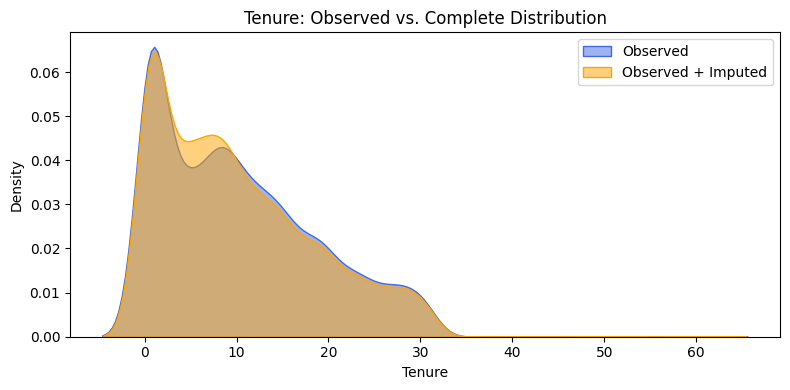

In [15]:
ks_distribution_check(observed_tenure, full_tenure, 'Tenure')

## WarehouseToHome

In [16]:
compare_missing_groups(df, 'WarehouseToHome')

--- Group: WarehouseToHome Present (n=5379) ---

Numerical summary statistics:
                              count        mean        std   min      25%  \
Churn                        5379.0    0.160625   0.367219   0.0    0.000   
Tenure                       5379.0   10.157698   8.429518   0.0    3.000   
CityTier                     5379.0    1.670013   0.920741   1.0    1.000   
HourSpendOnApp               5124.0    2.955308   0.722841   0.0    2.000   
NumberOfDeviceRegistered     5379.0    3.712958   1.023961   1.0    3.000   
SatisfactionScore            5379.0    3.066741   1.378057   1.0    2.000   
NumberOfAddress              5379.0    4.248001   2.586084   1.0    2.000   
Complain                     5379.0    0.282209   0.450116   0.0    0.000   
OrderAmountHikeFromlastYear  5114.0   15.701799   3.670846  11.0   13.000   
CouponUsed                   5123.0    1.790357   1.912415   0.0    1.000   
OrderCount                   5121.0    3.069713   2.974636   1.0    1.000 

In [17]:
warehousetohome_predictors = chi_square_missingness(df, 'WarehouseToHome', CANDIDATE_CATEGORICAL_COLS)

--- Chi-square tests: is WarehouseToHome missing ~ candidate feature ---

PreferredLoginDevice   chi2=   404.34   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=   660.32   p=0.0000   -> JUSTIFIED
Gender                 chi2=     0.12   p=0.7285   -> not significant
PreferedOrderCat       chi2=  1437.73   p=0.0000   -> JUSTIFIED
MaritalStatus          chi2=    11.07   p=0.0039   -> JUSTIFIED



**Result:** PreferredLoginDevice (chi2=404.34), PreferredPaymentMode (chi2=660.32), PreferedOrderCat (chi2=1437.73) and MaritalStatus (chi2=11.07, p=.004) are all significant; only Gender (p=.729) is not. MICE below uses the four significant predictors.

In [18]:
observed_warehousetohome, full_warehousetohome = mice_impute_column(df, 'WarehouseToHome', warehousetohome_predictors, min_value=0)

Observed-rows average WarehouseToHome: 15.640
Imputed-rows average  WarehouseToHome: 15.152


KS statistic: 0.0239   p-value: 0.0841
SUCCESS: imputed distribution is statistically indistinguishable from the observed one.


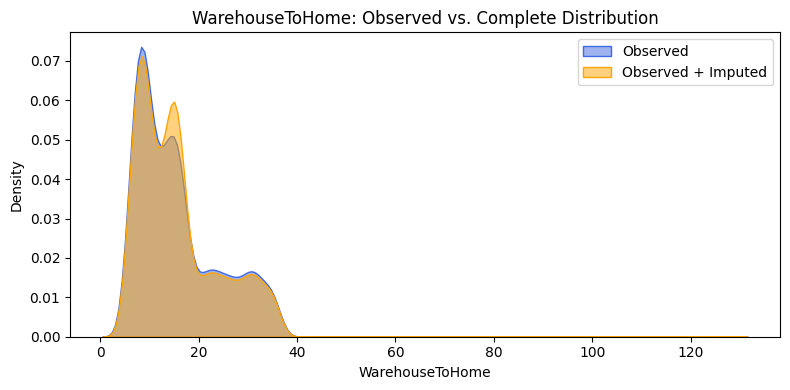

In [19]:
ks_distribution_check(observed_warehousetohome, full_warehousetohome, 'WarehouseToHome')

## HourSpendOnApp

In [20]:
compare_missing_groups(df, 'HourSpendOnApp')

--- Group: HourSpendOnApp Present (n=5375) ---

Numerical summary statistics:
                              count        mean        std   min      25%  \
Churn                        5375.0    0.165581   0.371739   0.0    0.000   
Tenure                       5375.0   10.174187   8.429793   0.0    3.000   
CityTier                     5375.0    1.664000   0.919659   1.0    1.000   
WarehouseToHome              5375.0   15.665875   8.363664   5.0    9.000   
NumberOfDeviceRegistered     5375.0    3.718140   1.018071   1.0    3.000   
SatisfactionScore            5375.0    3.069953   1.381446   1.0    2.000   
NumberOfAddress              5375.0    4.274419   2.582406   1.0    2.000   
Complain                     5375.0    0.285953   0.451909   0.0    0.000   
OrderAmountHikeFromlastYear  5110.0   15.723288   3.675546  11.0   13.000   
CouponUsed                   5119.0    1.789998   1.898831   0.0    1.000   
OrderCount                   5117.0    3.062537   2.962958   1.0    1.000  

In [21]:
hourspendonapp_predictors = chi_square_missingness(df, 'HourSpendOnApp', ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat'])

--- Chi-square tests: is HourSpendOnApp missing ~ candidate feature ---

PreferredLoginDevice   chi2=   421.19   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=   330.41   p=0.0000   -> JUSTIFIED
PreferedOrderCat       chi2=  1368.64   p=0.0000   -> JUSTIFIED



Only these three candidates are tested for this column (Gender and MaritalStatus were not examined here).  
**Result:** All three tested features are significant at p < .001 -- PreferredLoginDevice (chi2=421.19), PreferredPaymentMode (chi2=330.41) and PreferedOrderCat (chi2=1368.64) -- so all three feed into MICE below.

In [22]:
observed_hourspendonapp, full_hourspendonapp = mice_impute_column(df, 'HourSpendOnApp', hourspendonapp_predictors, min_value=0)

Observed-rows average HourSpendOnApp: 2.932
Imputed-rows average  HourSpendOnApp: 2.473


KS statistic: 0.0324   p-value: 0.0060


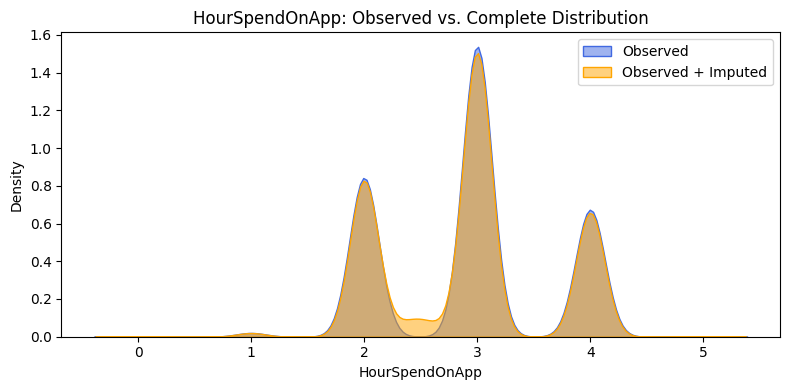

In [23]:
ks_distribution_check(observed_hourspendonapp, full_hourspendonapp, 'HourSpendOnApp')

## OrderAmountHikeFromlastYear

In [24]:
compare_missing_groups(df, 'OrderAmountHikeFromlastYear')

--- Group: OrderAmountHikeFromlastYear Present (n=5365) ---

Numerical summary statistics:
                           count        mean        std  min     25%     50%  \
Churn                     5365.0    0.174091   0.379223  0.0    0.00    0.00   
Tenure                    5365.0    9.459694   8.154844  0.0    2.00    8.00   
CityTier                  5365.0    1.663933   0.919897  1.0    1.00    1.00   
WarehouseToHome           5365.0   15.695261   8.360770  5.0    9.00   14.00   
HourSpendOnApp            5365.0    2.901714   0.713605  0.0    2.00    3.00   
NumberOfDeviceRegistered  5365.0    3.676048   1.028941  1.0    3.00    4.00   
SatisfactionScore         5365.0    3.066356   1.381025  1.0    2.00    3.00   
NumberOfAddress           5365.0    4.173346   2.578477  1.0    2.00    3.00   
Complain                  5365.0    0.286300   0.452073  0.0    0.00    0.00   
CouponUsed                5109.0    1.683500   1.796369  0.0    1.00    1.00   
OrderCount                510

In [25]:
orderamounthikefromlastyear_predictors = chi_square_missingness(df, 'OrderAmountHikeFromlastYear', CANDIDATE_CATEGORICAL_COLS)

--- Chi-square tests: is OrderAmountHikeFromlastYear missing ~ candidate feature ---

PreferredLoginDevice   chi2=   122.63   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=    56.15   p=0.0000   -> JUSTIFIED
Gender                 chi2=     6.10   p=0.0135   -> JUSTIFIED
PreferedOrderCat       chi2=  3029.10   p=0.0000   -> JUSTIFIED
MaritalStatus          chi2=    16.55   p=0.0003   -> JUSTIFIED



**Result:** All five candidate features are significant -- PreferredLoginDevice (chi2=122.63), PreferredPaymentMode (chi2=56.15), Gender (chi2=6.10, p=.014), PreferedOrderCat (chi2=3029.10) and MaritalStatus (chi2=16.55, p<.001) -- so MICE below uses all five.

In [26]:
observed_orderamounthikefromlastyear, full_orderamounthikefromlastyear = mice_impute_column(df, 'OrderAmountHikeFromlastYear', orderamounthikefromlastyear_predictors, min_value=0)

Observed-rows average OrderAmountHikeFromlastYear: 15.708
Imputed-rows average  OrderAmountHikeFromlastYear: 15.852


KS statistic: 0.0268   p-value: 0.0381


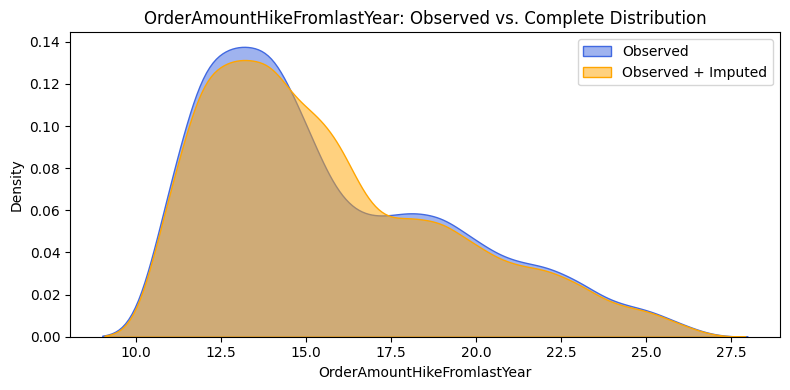

In [27]:
ks_distribution_check(observed_orderamounthikefromlastyear, full_orderamounthikefromlastyear, 'OrderAmountHikeFromlastYear')

## CouponUsed

In [28]:
compare_missing_groups(df, 'CouponUsed')

--- Group: CouponUsed Present (n=5374) ---

Numerical summary statistics:
                              count        mean        std   min       25%  \
Churn                        5374.0    0.174916   0.379931   0.0    0.0000   
Tenure                       5374.0    9.514190   8.172323   0.0    2.0000   
CityTier                     5374.0    1.658727   0.917407   1.0    1.0000   
WarehouseToHome              5374.0   15.674931   8.325672   5.0    9.0000   
HourSpendOnApp               5374.0    2.921975   0.711584   0.0    2.0000   
NumberOfDeviceRegistered     5374.0    3.699479   1.027054   1.0    3.0000   
SatisfactionScore            5374.0    3.066617   1.380931   1.0    2.0000   
NumberOfAddress              5374.0    4.186825   2.586398   1.0    2.0000   
Complain                     5374.0    0.285076   0.451493   0.0    0.0000   
OrderAmountHikeFromlastYear  5374.0   15.729762   3.572139  11.0   13.0000   
OrderCount                   5116.0    2.915754   2.809587   1.0    

In [29]:
couponused_predictors = chi_square_missingness(df, 'CouponUsed', CANDIDATE_CATEGORICAL_COLS)

--- Chi-square tests: is CouponUsed missing ~ candidate feature ---

PreferredLoginDevice   chi2=   107.60   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=    40.23   p=0.0000   -> JUSTIFIED
Gender                 chi2=     5.76   p=0.0164   -> JUSTIFIED
PreferedOrderCat       chi2=  1973.52   p=0.0000   -> JUSTIFIED
MaritalStatus          chi2=     4.56   p=0.1023   -> not significant



**Result:** PreferredLoginDevice (chi2=107.60), PreferredPaymentMode (chi2=40.23), Gender (chi2=5.76, p=.016) and PreferedOrderCat (chi2=1973.52) are significant; MaritalStatus (p=.102) is not. MICE below uses the four significant predictors. Coupon counts are discrete, so the result is rounded to the nearest integer.

In [30]:
observed_couponused, full_couponused = mice_impute_column(df, 'CouponUsed', couponused_predictors, min_value=0, round_result=True, as_int=True)

Observed-rows average CouponUsed: 1.751
Imputed-rows average  CouponUsed: 2.598


KS statistic: 0.0083   p-value: 0.9910
SUCCESS: imputed distribution is statistically indistinguishable from the observed one.


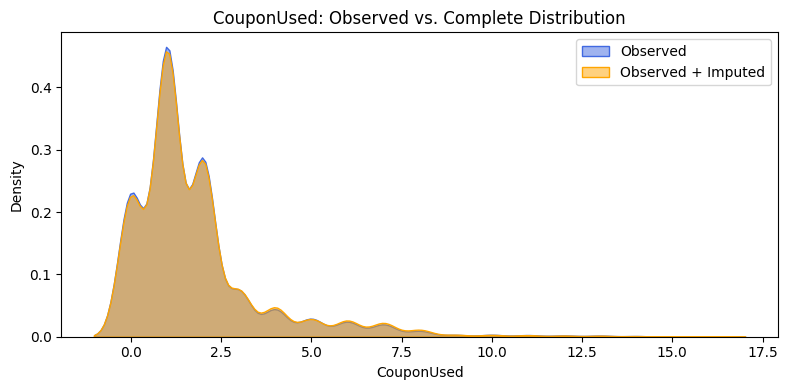

In [31]:
ks_distribution_check(observed_couponused, full_couponused, 'CouponUsed')

## OrderCount

In [32]:
compare_missing_groups(df, 'OrderCount')

--- Group: OrderCount Present (n=5372) ---

Numerical summary statistics:
                              count        mean        std   min     25%  \
Churn                        5372.0    0.173120   0.378386   0.0    0.00   
Tenure                       5372.0    9.629050   8.274239   0.0    2.00   
CityTier                     5372.0    1.657483   0.915715   1.0    1.00   
WarehouseToHome              5372.0   15.478421   8.262910   5.0    9.00   
HourSpendOnApp               5372.0    2.908357   0.708649   0.0    2.00   
NumberOfDeviceRegistered     5372.0    3.688198   1.016411   1.0    3.00   
SatisfactionScore            5372.0    3.062174   1.382204   1.0    2.00   
NumberOfAddress              5372.0    4.162882   2.563674   1.0    2.00   
Complain                     5372.0    0.281459   0.449753   0.0    0.00   
OrderAmountHikeFromlastYear  5372.0   15.704531   3.575993  11.0   13.00   
CouponUsed                   5372.0    1.758935   1.887293   0.0    1.00   
DaySinceLastOr

In [33]:
ordercount_predictors = chi_square_missingness(df, 'OrderCount', CANDIDATE_CATEGORICAL_COLS)

--- Chi-square tests: is OrderCount missing ~ candidate feature ---

PreferredLoginDevice   chi2=    78.28   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=   106.52   p=0.0000   -> JUSTIFIED
Gender                 chi2=    12.88   p=0.0003   -> JUSTIFIED
PreferedOrderCat       chi2=  1071.94   p=0.0000   -> JUSTIFIED
MaritalStatus          chi2=     8.69   p=0.0130   -> JUSTIFIED



**Result:** All five candidate features are significant -- PreferredLoginDevice (chi2=78.28), PreferredPaymentMode (chi2=106.52), Gender (chi2=12.88, p<.001), PreferedOrderCat (chi2=1071.94) and MaritalStatus (chi2=8.69, p=.013) -- so MICE below uses all five. Order counts are discrete and can't be zero, so the result is rounded with a floor of 1.

In [34]:
observed_ordercount, full_ordercount = mice_impute_column(df, 'OrderCount', ordercount_predictors, min_value=1, round_result=True)

Observed-rows average OrderCount: 3.008
Imputed-rows average  OrderCount: 4.609


KS statistic: 0.0221   p-value: 0.1340
SUCCESS: imputed distribution is statistically indistinguishable from the observed one.


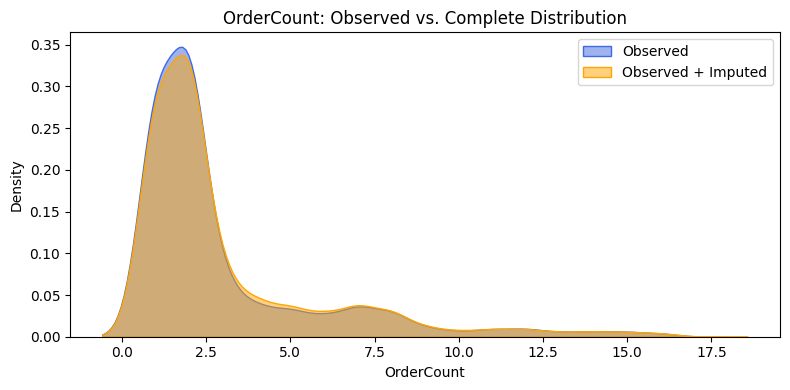

In [35]:
ks_distribution_check(observed_ordercount, full_ordercount, 'OrderCount')

## DaySinceLastOrder

In [36]:
compare_missing_groups(df, 'DaySinceLastOrder')

--- Group: DaySinceLastOrder Present (n=5323) ---

Numerical summary statistics:
                              count        mean        std   min         25%  \
Churn                        5323.0    0.167950   0.373857   0.0    0.000000   
Tenure                       5323.0    9.879440   8.421017   0.0    2.358337   
CityTier                     5323.0    1.639865   0.909119   1.0    1.000000   
WarehouseToHome              5323.0   15.588217   8.347686   5.0    9.000000   
HourSpendOnApp               5323.0    2.896054   0.712511   0.0    2.000000   
NumberOfDeviceRegistered     5323.0    3.663160   1.026431   1.0    3.000000   
SatisfactionScore            5323.0    3.070073   1.378750   1.0    2.000000   
NumberOfAddress              5323.0    4.185985   2.583294   1.0    2.000000   
Complain                     5323.0    0.285741   0.451809   0.0    0.000000   
OrderAmountHikeFromlastYear  5323.0   15.687909   3.574394  11.0   13.000000   
CouponUsed                   5323.0    

In [37]:
daysincelastorder_predictors = chi_square_missingness(df, 'DaySinceLastOrder', CANDIDATE_CATEGORICAL_COLS)

--- Chi-square tests: is DaySinceLastOrder missing ~ candidate feature ---

PreferredLoginDevice   chi2=    97.71   p=0.0000   -> JUSTIFIED
PreferredPaymentMode   chi2=   122.25   p=0.0000   -> JUSTIFIED
Gender                 chi2=     0.00   p=1.0000   -> not significant
PreferedOrderCat       chi2=  1015.76   p=0.0000   -> JUSTIFIED
MaritalStatus          chi2=     2.29   p=0.3183   -> not significant



**Result:** PreferredLoginDevice (chi2=97.71), PreferredPaymentMode (chi2=122.25) and PreferedOrderCat (chi2=1015.76) are significant; Gender (p=1.00) and MaritalStatus (p=.318) are not. MICE below uses only the three significant predictors.

In [38]:
observed_daysincelastorder, full_daysincelastorder = mice_impute_column(df, 'DaySinceLastOrder', daysincelastorder_predictors, min_value=0)

Observed-rows average DaySinceLastOrder: 4.543
Imputed-rows average  DaySinceLastOrder: 6.285


KS statistic: 0.0294   p-value: 0.0172


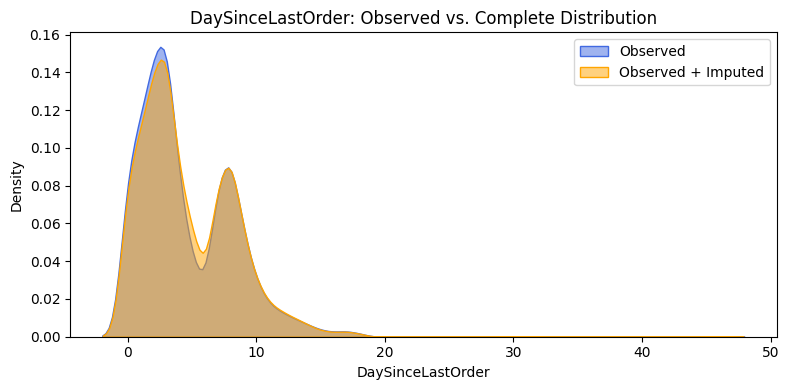

In [39]:
ks_distribution_check(observed_daysincelastorder, full_daysincelastorder, 'DaySinceLastOrder')

# Dtype Cleanup & Outlier Review

In [ ]:
df['Churn'] = df['Churn'].astype('category')
df['CityTier'] = df['CityTier'].astype('category')
print(df.dtypes)

In [ ]:
# Boxplots to review outliers across all numeric columns
numerical_cols = df.select_dtypes(include='number').columns.drop('CustomerID', errors='ignore')
num_cols_subplot = 3
num_rows_subplot = math.ceil(len(numerical_cols) / num_cols_subplot)

fig, axes = plt.subplots(num_rows_subplot, num_cols_subplot, figsize=(15, 5 * num_rows_subplot))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Several columns show many outliers, which often means the underlying distribution is skewed
rather than that the data is wrong. Next step is to look at each distribution individually and decide
whether a transform (e.g. log) is warranted. Outliers should only be deleted outright when they're
confirmed data-entry errors (e.g. an impossible value) and there's enough data to spare -- not simply
because they're extreme.

In [ ]:
# Distribution of each numeric column (excluding the target, Churn)
numerical_cols = df.select_dtypes(include='number').columns.drop(['CustomerID', 'Churn'], errors='ignore')
num_cols_subplot = 3
num_rows_subplot = math.ceil(len(numerical_cols) / num_cols_subplot)

fig, axes = plt.subplots(num_rows_subplot, num_cols_subplot, figsize=(15, 5 * num_rows_subplot))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()